<a href="https://colab.research.google.com/github/kamat-v/qc-course-materials/blob/main/notebooks/week02_single_qubit_systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Working with single-qubit systems in Qiskit

In [1]:
!pip install qiskit qiskit_aer qiskit-ibm-runtime pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.6/378.6 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 13.1 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=2639e52a9d61649f348893aa4b7365298d449d8499b1897a8589ca5d05cff878
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a17

In [2]:
from qiskit import QuantumCircuit
import numpy as np
import matplotlib.pyplot as plt

**1. An example of a quantum circuit**

In [3]:
circuit=QuantumCircuit(1) #Creating an empty, one-qubit circuit

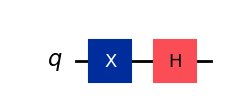

In [4]:
circuit.x(0) #Apply an X gate
circuit.h(0) #Apply an H gate
circuit.draw("mpl") #Display

**2. Another example -- the phase shift gate $P(\theta)$**


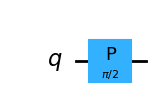

In [5]:
circuit_two=QuantumCircuit(1)
circuit_two.p(np.pi/2,0)
circuit_two.draw("mpl")

**3. Simulating state evolution**

Let us simulate the evolution of the state vector by a quantum circuit.

In [6]:
from qiskit.quantum_info import Statevector

In [7]:
state=Statevector(circuit)
print(state)

Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


In [8]:
state_two=Statevector(circuit_two)
print(state_two)


Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


**4. Getting measurement samples from a simulator**

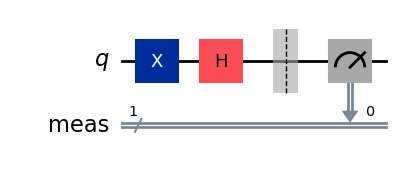

In [10]:
circuit.measure_all()
circuit.draw("mpl")

In [11]:
from qiskit_aer import AerSimulator
backend=AerSimulator(seed_simulator=18620123)

In [12]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
sampler=Sampler(backend)

In [13]:
job=sampler.run([circuit], shots=1024) # sample any number of times
result=job.result()[0].data.meas # Getting the results
print(result.get_counts())

{'0': 505, '1': 519}


**5. Constructive vs Destructive Interference**

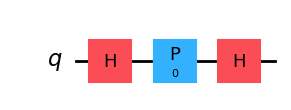

In [16]:
#Circuit demonstrating constructive interference
circuit_three=QuantumCircuit(1)
circuit_three.h(0)
circuit_three.p(0,0)
circuit_three.h(0)
circuit_three.draw("mpl")

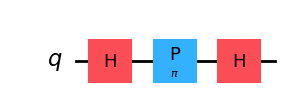

In [17]:
#Circuit demonstrating destructive interference
circuit_four=QuantumCircuit(1)
circuit_four.h(0)
circuit_four.p(np.pi,0)
circuit_four.h(0)
circuit_four.draw("mpl")

In [18]:
circuit_three.measure_all()
job=sampler.run([circuit_three], shots=1024) # sample any number of times
result=job.result()[0].data.meas # Getting the results
print(result.get_counts())

{'0': 1024}


In [19]:
circuit_four.measure_all()
job=sampler.run([circuit_four], shots=1024) # sample any number of times
result=job.result()[0].data.meas # Getting the results
print(result.get_counts())

{'1': 1024}
